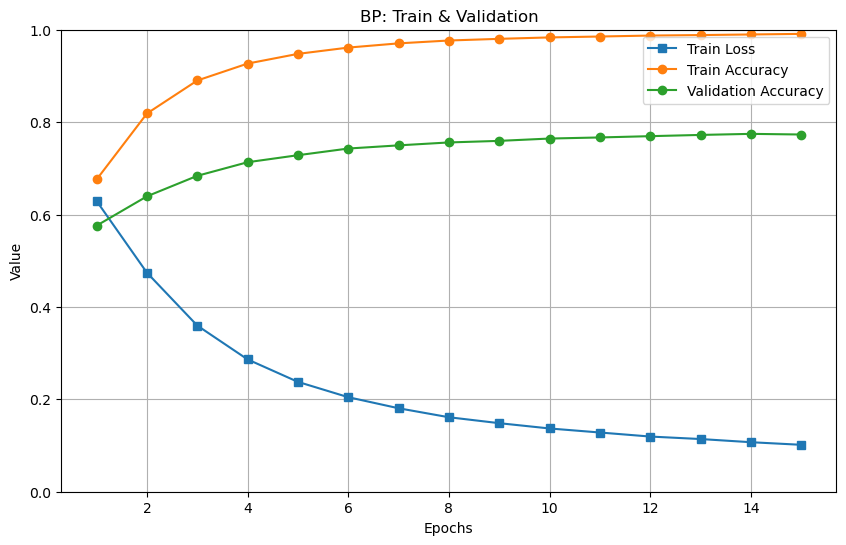

In [15]:
import re
import matplotlib.pyplot as plt

with open("Result_BP.txt", "r", encoding="utf-8") as f:
    text = f.read()

winacc = list(map(float, re.findall(r"WinAcc\(5000\): ([0-9.]+)", text)))
winloss = list(map(float, re.findall(r"WinAvgLoss\(5000\): ([0-9.]+)", text)))
stm_acc = list(map(float, re.findall(r"STM32 inference accuracy = ([0-9.]+)", text)))

def group_avg(data, group_size=6):
    return [
        sum(data[i:i+group_size]) / group_size
        for i in range(0, len(data), group_size)
        if len(data[i:i+group_size]) == group_size
    ]

winacc_avg = group_avg(winacc)
winloss_avg = group_avg(winloss)

min_len = min(len(winacc_avg), len(winloss_avg), len(stm_acc))
winacc_avg = winacc_avg[:min_len]
winloss_avg = winloss_avg[:min_len]
stm_acc = stm_acc[:min_len]


x = list(range(1, min_len + 1))

plt.figure(figsize=(10, 6))

plt.plot(x, winloss_avg, marker='s', label='Train Loss')
plt.plot(x, winacc_avg, marker='o', label='Train Accuracy')
plt.plot(x, stm_acc, marker='o', label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Value")
plt.ylim([0, 1])
plt.title("BP: Train & Validation")
plt.legend()
plt.grid()

plt.show()